# Bonus 1 – Aufgabenstellung

Am Institut für Geophysik der ETH werden Messungen von Bodenschwingungen durchgeführt. Für ein neues Projekt möchten die Forschenden eine Methode entwickeln, mit der unterschiedliche Quellen seismischer Signale anhand kurzer Messungen identifiziert werden können.

Die gemessenen Daten einer ersten Testmessung befinden sich hier, wobei die erste Spalte die Zeit in Sekunden angibt, die zweite Spalte das gemessene Signal in Volt (Signal der Bodenschwingung plus Sensorrauschen) und die dritte Spalte das Sensorsignal in Volt enthält, bei dem keine äussere Anregung vorliegt (nur Sensorrauschen). Da dieses Rauschsignal zu einem anderen Zeitpunkt als das Vibrationssignal aufgenommen wurde, kann keine einfache direkte Subtraktion der beiden Signale vorgenommen werden.

**Frage 1:**
In der Messung sind Bodenschwingungen enthalten, die von einer dominanten Quelle verursacht werden. Typische Frequenzbereiche sind mikroseismische Wellen (Ozean) mit 0.1–0.5 Hz, kleine seismische Ereignisse mit 1–10 Hz sowie Maschinenvibrationen (Industrie) mit 20–60 Hz. Um welche Quelle handelt es sich bei dieser Messung?
*Tipp: Berechnen Sie die spektrale Leistungsdichte des gemessenen Signals.*

**Antwort 1:** Es handelt sich bei dieser Aufnahme um **ein kleines seismisches Ereignis** — korrekt (2P).

**Frage 2:**
Die Varianz des gemessenen Signals setzt sich aus einem Beitrag der Bodenschwingung und einem Beitrag des Sensorrauschens zusammen. Angenommen, beide Beiträge sind unkorreliert. Wie gross ist die Varianz der Bodenschwingung allein?

**Antwort 2:** Die Varianz der Bodenschwingung beträgt **0.001247 V²** — korrekt (3P).

**Frage 3:**
Zur Überprüfung der Annahme aus der vorherigen Aufgabe wird die Kovarianz zwischen dem gemessenen Signal (Bodenschwingung plus Sensorrauschen) und dem reinen Sensorsignal bestimmt.

**Antwort 3:** Es gilt: **Die Kovarianz ist näherungsweise null.** — korrekt (2P).

**Frage 4:**
In einem zweiten Datensatz (hier) sind die Zeitabstände zwischen aufeinanderfolgenden kleinen seismischen Ereignissen in Sekunden gespeichert. Wir nehmen an, dass diese Zeitabstände exponentialverteilt sind.

Für eine exponentialverteilte Zufallsvariable T mit mittlerer Wartezeit τ gilt für die Wahrscheinlichkeit, dass ein Ereignis innerhalb eines Zeitintervalls t auftritt: $P(T \le t) = 1 - \exp(-t/\tau)$

Bestimmen Sie zunächst die mittlere Wartezeit τ aus dem Datensatz und berechnen Sie damit die Wahrscheinlichkeit, dass innerhalb der nächsten 30 s ein weiteres Ereignis auftritt.

**Antwort 4:** Die Wahrscheinlichkeit beträgt **55.3953 %** — korrekt (2P).

8.0


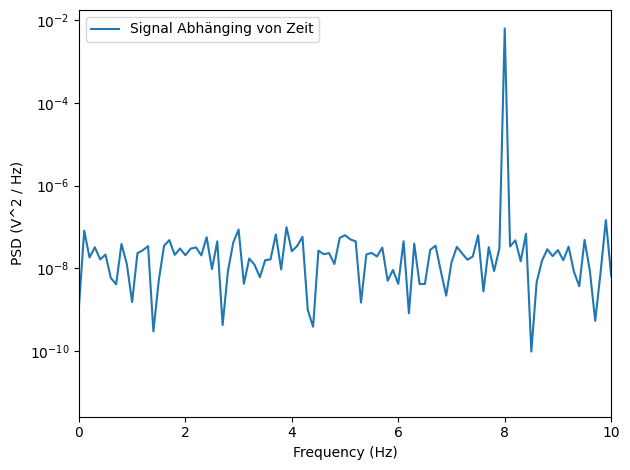

In [36]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

data = np.loadtxt('data/seismic_test_dataset.txt', skiprows=1, delimiter=',')

time_s = data[:,0]
signal_V = data[:,1]
sensor_noise_V = data[:,2]

# plt.plot(time_s, signal_V)

def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title='', xlim=None, ylim=None):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()

def compute_psd(signal, t, return_spectrum=False):
    dt = t[1] - t[0]
    N = len(t)
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    psd = dt / N * np.abs(spectrum) ** 2
    mask = frequency >= 0
    if return_spectrum:
        return frequency[mask], psd[mask], spectrum
    return frequency[mask], psd[mask]

freq, psd = compute_psd(signal_V, time_s)

print(freq[np.argmax(psd)])

plot_plot(
    (freq, psd, 'Signal Abhänging von Zeit'),
    xlabel='Frequency (Hz)',
    ylabel='PSD (V^2 / Hz)',
    scale='logy',
    xlim=(0, 10)
)

In [37]:
print(np.var(signal_V))
print(np.var(sensor_noise_V))

print(np.var(signal_V) - np.var(sensor_noise_V))

0.0012724760448166426
2.5048033039491148e-05
0.0012474280117771514


In [38]:

cov_np = np.cov(signal_V, sensor_noise_V)[0, 1]

print(cov_np)

-2.4834940141162054e-06


In [39]:
waiting_time_s = np.loadtxt('data/earthquake_waiting_times.txt', skiprows=1)

#print(waiting_time_s)

tau = np.mean(waiting_time_s)

def prob(tau, t):
    return 1 - np.exp(-t / tau)

print(prob(tau, 30) * 100)

55.3953411171735


---

# Bonus 2 – Aufgabenstellung

Ein Umwelttechnik-Startup entwickelt einen mobilen Feinstaub-Sensor, mit dem die Luftqualität innerhalb weniger Minuten bestimmt werden kann. Das Gerät soll insbesondere in urbanen Gebieten eingesetzt werden, um kritisch erhöhte PM2.5-Feinstaubwerte frühzeitig zu erkennen.

Jede Messung wird dabei in zwei Klassen eingeteilt:
- kritisch belastet (1)
- unkritisch belastet (0)

Zur Validierung wird jede Sensormessung parallel mit einem als fehlerfrei angenommenen Referenzgerät durchgeführt.

Im Rahmen einer Studie wird untersucht, wie die Trefferquote des Sensors von der Messdauer x (in Minuten) abhängt. Der Datensatz (hier) enthält dazu die Messdauer x in Minuten (Spalte 1), die Klassifikation des Sensors ((0/1), Spalte 2) und die Klassifikation des Referenzgeräts ((0/1), Spalte 3). Es werden 25 verschiedene Messdauern untersucht. Für jede Messdauer werden jeweils 2000 unabhängige Messungen durchgeführt.

## Teil 1: Trefferquote

Für jede Messdauer x wird die empirische Trefferquote definiert als y(x) = (Anzahl korrekter Messungen bei Messdauer x) / (Anzahl aller Messungen bei Messdauer x).

Die Trefferquote y(x) hängt von der Messdauer x ab. Wir modellieren die Trefferquote durch die Exponentialfunktion: $y = 1 - a e^{bx}$.

Bestimmen Sie dazu zunächst die 25 Werte y(x) aus den Rohdaten. Führen Sie anschliessend eine lineare Regression mittels einer geeigneten Linearisierung durch. Alle 25 Datenpunkte sollen gleich gewichtet werden. Für alle gegebenen Messdauern gilt y<1. Daher ist ln(1−y) für alle Datenpunkte definiert.

**Frage 1:** Wie lauten die Fitparameter a und b?
**Antwort 1:** a = **0.58379**, b = **-0.44769 1/min** — korrekt.

**Frage 2:** Wie gross ist die mit dem Fitmodell berechnete Trefferquote bei x = 3.0 Minuten? Welche minimale Messdauer wird benötigt, um mindestens 85% korrekte Messungen zu erreichen?
**Antwort 2:** Bei x = 3.0 min beträgt die Trefferquote **84.76038 %**; die minimale Messdauer beträgt **3.03540 min** — korrekt.

## Teil 2: Statistische Unsicherheit

Für eine feste Messdauer ist jede Messung entweder korrekt oder falsch. Betrachten Sie x = 3.0 Minuten mit N = 2000 Messungen und verwenden Sie für die Trefferquote den Fitwert aus Frage 2. Nehmen Sie an, dass die Trefferquote näherungsweise normalverteilt ist.

**Frage 3:** Wie gross ist die Standardabweichung der Trefferquote? Geben Sie σ_y als dimensionslose Trefferquote an.
**Antwort 3:** σ_y = **0.00804** — korrekt.

**Frage 4:** Bestimmen Sie das 2σ-Intervall der Trefferquote.
**Antwort 4:** Untere Grenze = **83.15307 %**, Obere Grenze = **86.36769 %** — korrekt.

## Teil 3: Fehlerfortpflanzung durch unsichere Messdauer

Im Alltag lässt sich die Messdauer nicht exakt kontrollieren. Angenommen, die Messdauer ist mit einer Standardabweichung von σ_x = 0.2 min behaftet.

**Frage 5:** Bestimmen Sie mithilfe der Gauss-Fehlerfortpflanzung den zusätzlichen Fehler der Trefferquote bei x = 3.0 min. Geben Sie das Resultat in Prozentpunkten an.
**Antwort 5:** **1.36451 %** — korrekt.

## Teil 4: Bayes'sche Auswertung

In einer bestimmten Stadt liegt die Wahrscheinlichkeit für kritisch erhöhte Feinstaubbelastung bei 25%. Ein Sensor misst bei x = 3.0 min und zeigt „kritisch“ an.

Hinweise:
1. Verwenden Sie den Satz von Bayes.
2. Sie dürfen symmetrische Wahrscheinlichkeiten annehmen, d.h. (Wahrscheinlichkeit falsch positives Testergebnis) = 1 − (Wahrscheinlichkeit korrekt positives Testergebnis)

**Frage 6:** Wie gross ist die Wahrscheinlichkeit, dass tatsächlich eine kritische Belastung vorliegt, wenn der Sensor eine kritische Belastung misst?
*(Antwort/Punktestand für Frage 6 war im Screenshot nicht sichtbar.)*

In [40]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title='', xlim=None, ylim=None):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()

def compute_psd(signal, t, return_spectrum=False):
    dt = t[1] - t[0]
    N = len(t)
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    psd = dt / N * np.abs(spectrum) ** 2
    mask = frequency >= 0
    if return_spectrum:
        return frequency[mask], psd[mask], spectrum
    return frequency[mask], psd[mask]
    

In [41]:
data = np.loadtxt('data/luftsensor_studie.txt', skiprows=1, delimiter=',')
duration = data[:,0]
sensor = data[:,1]
referenz = data[:,2]

unique_durations = np.unique(duration)
y_vals = []

for d in unique_durations:
    mask = (duration == d)
    total = np.sum(mask)
    correct = np.sum(sensor[mask] == referenz[mask])
    y_vals.append(correct / total)

b_fit, ln_a = np.polyfit(unique_durations, np.log(1 - np.array(y_vals)), 1)
a_fit = np.exp(ln_a)

print(f"a = {a_fit:.5f}")
print(f"b = {b_fit:.5f} 1/min")

a = 0.58379
b = -0.44769 1/min


In [42]:
def accuracy_func(t):
    return 1 - a_fit * np.exp(b_fit * t)

print(f"Accuracy at 3 min = {accuracy_func(3) * 100:.5f}%")

def get_time_for_acc(acc):
    return (np.log((1 - acc) / a_fit)) / b_fit

print(f"Time needed for 85% acc = {get_time_for_acc(0.85):.5f} min")

Accuracy at 3 min = 84.76038%
Time needed for 85% acc = 3.03540 min


In [43]:
t = 3.0
p = accuracy_func(t)

N = 2000

sigma_y = np.sqrt(p * (1 - p) / N)
print(f"sigma = {sigma_y:.5f}")

sigma = 0.00804


In [44]:
untere_prozent = (p - 2*sigma_y) * 100
obere_prozent = (p + 2*sigma_y) * 100
print(f"Untere Grenze = {untere_prozent:.5f}%")
print(f"Obere Grenze = {obere_prozent:.5f}%")

Untere Grenze = 83.15307%
Obere Grenze = 86.36769%


In [45]:
x_val = 3.0
sigma_x = 0.2

dy_dx = -a_fit * b_fit * np.exp(b_fit * x_val)

print(f"{dy_dx * sigma_x * 100:.5f}%")


1.36451%


In [46]:
p_K = 0.25
t = 3.0
p_M = accuracy_func(t)

p_K_M = (p_M * p_K) / ((p_M * p_K) + ((1 - p_M) * (1 - p_K)))

print(f"Warscheinlichkeit einer Kritischne Belastung: {p_K_M * 100:.5f}%")

Warscheinlichkeit einer Kritischne Belastung: 64.96082%


In [47]:
p_K = p_K_M
t = 3.0
p_M = accuracy_func(t)

p_K_M_2 = (p_M * p_K) / ((p_M * p_K) + ((1 - p_M) * (1 - p_K)))

print(f"Warscheinlichkeit einer Kritischne Belastung: {p_K_M_2 * 100:.5f}%")

Warscheinlichkeit einer Kritischne Belastung: 91.15934%


---

# Bonus 3 – Aufgabenstellung

In dieser Aufgabe trainieren Sie ein Modell und klassifizieren anschliessend Punkte in ℝ³.
Laden Sie zunächst das Aufgaben-Template (`bonus3.ipynb`) und die Trainingsdaten (`data.csv`) herunter. Genaue Anweisungen zum Bearbeiten der Aufgabe erhalten Sie im Template.

**Achtung:** Beim Template und den Trainingsdaten handelt es sich unabhängig vom Versuch stets um die gleichen Files.

Nach dem Trainieren und Validieren Ihres Modells sollen Sie die Punkte eines neuen Datensatzes klassifizieren, für den Sie die richtigen Labels nicht kennen.

**Achtung:** Mit jedem neuen Versuch erhalten Sie einen neuen, zufällig ausgewählten Datensatz!

**Frage 1:** Wie lautet die Klassifizierung der Punkte im neuen Datensatz?

| Reihe | Klasse (korrekt) |
|---|---|
| 0 | 1 |
| 1 | 0 |
| 2 | 1 |
| 3 | 0 |
| 4 | 1 |
| 5 | 0 |

Alle sechs Antworten korrekt (1.00 von 1.00 Punkten je Frage).

## Beschreibung der Aufgabe

In dieser Aufgabe implementieren Sie ein Programm, das lernt, Punkte in $\mathbb{R}^3$ zu klassifizieren.


Wenn Sie den Datensatz `data.csv` mit Pandas einlesen, sollten Sie ein DataFrame erhalten, dessen erste Zeilen wie folgt aussehen:

```
        X1	        X2	        X3	        Target
0	8445.571173	-0.050477	90.099035	0
1	-4371.072247	-0.037678	38.123484	0
2	952.449974	-0.068132	123.125480	1
3	-4863.485339	-0.039208	74.353420	0
4	2548.778727	-0.050234	110.789678	1
```

Jede Zeile stellt einen Punkt dar. Die letzte Spalte, `Target`, enthält die Klasse des Punktes als Ganzzahl: entweder 0 oder 1. Alle anderen Spalten beschreiben die Koordinaten des Punktes.

### Ihre Aufgabe

Nutzen Sie Pandas und Scikit-learn, um ein Modell auf den Daten zu trainieren und dieses zu validieren.  Verwenden Sie dann wiederum Pandas, um den neuen Datensatz zu laden. Dieser sollte die gleiche Struktur haben, jedoch fehlt die Spalte `Target`. Verwenden Sie Ihr trainiertes Modell, um die Klasse für diese Punkte vorherzusagen. Geben Sie die entsprechende Vorhersage für jeden Punkt aus und tragen Sie diese in Moodle ein. 

*Hinweis:* 
- Wenn Sie die Trainingsdaten vorverarbeiten, müssen Sie darauf achten, dass Sie den neuen Datensatz auf genau dieselbe Weise vorverarbeiten.

In [48]:
# Einlesen der Daten

# Ihr Code
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

# Trainingsdaten laden
train_data = pd.read_csv('data/ensemble_train.csv')
print("Trainingsdaten:")
print(train_data.head())
print(f"\nShape: {train_data.shape}")
print(f"Target Verteilung:\n{train_data['Target'].value_counts()}")

Trainingsdaten:
            X1        X2          X3  Target
0  8445.571173 -0.050477   90.099035       0
1 -4371.072247 -0.037678   38.123484       0
2   952.449974 -0.068132  123.125480       1
3 -4863.485339 -0.039208   74.353420       0
4  2548.778727 -0.050234  110.789678       1

Shape: (2000, 4)
Target Verteilung:
Target
0    1021
1     979
Name: count, dtype: int64


In [49]:
# Vorverarbeitung der Daten

# Ihr Code
X = train_data[['X1', 'X2', 'X3']]
y = train_data['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Nach der Skalierung:")
print(f"Mean von X1: {X_scaled[:, 0].mean():.2f} (sollte nahe 0 sein)")
print(f"Std von X1: {X_scaled[:, 0].std():.2f} (sollte nahe 1 sein)")


Nach der Skalierung:
Mean von X1: 0.00 (sollte nahe 0 sein)
Std von X1: 1.00 (sollte nahe 1 sein)


In [50]:
# Model Trainieren und validieren

# Ihr Code
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

RFC = RandomForestClassifier(n_estimators=100, random_state=42)
RFC.fit(X_train, y_train)

LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

SVM = SVC(kernel='rbf', random_state=42)
SVM.fit(X_train, y_train)

GB = GradientBoostingClassifier(n_estimators=100, random_state=42)
GB.fit(X_train, y_train)

AB = AdaBoostClassifier(n_estimators=100, random_state=42)
AB.fit(X_train, y_train)

ET = ExtraTreesClassifier(n_estimators=100, random_state=42)
ET.fit(X_train, y_train)

y_pred1 = RFC.predict(X_val)
accuracy1 = accuracy_score(y_val, y_pred1)
print(f"Validierungsgenauigkeit (Random Forest):            {accuracy1:.4f}     ({accuracy1*100:.2f}%)")

y_pred2 = LR.predict(X_val)
accuracy2 = accuracy_score(y_val, y_pred2)
print(f"Validierungsgenauigkeit (Logistic Regression):      {accuracy2:.4f}     ({accuracy2*100:.2f}%)")

y_pred3 = SVM.predict(X_val)
accuracy3 = accuracy_score(y_val, y_pred3)
print(f"Validierungsgenauigkeit (SVM):                      {accuracy3:.4f}     ({accuracy3*100:.2f}%)")

y_pred4 = GB.predict(X_val)
accuracy4 = accuracy_score(y_val, y_pred4)
print(f"Validierungsgenauigkeit (Gradient Boosting):        {accuracy4:.4f}     ({accuracy4*100:.2f}%)")

y_pred5 = AB.predict(X_val)
accuracy5 = accuracy_score(y_val, y_pred5)
print(f"Validierungsgenauigkeit (AdaBoost):                 {accuracy5:.4f}     ({accuracy5*100:.2f}%)")

y_pred6 = ET.predict(X_val)
accuracy6 = accuracy_score(y_val, y_pred6)
print(f"Validierungsgenauigkeit (Extra Trees):              {accuracy6:.4f}     ({accuracy6*100:.2f}%)")

Validierungsgenauigkeit (Random Forest):            0.8575     (85.75%)
Validierungsgenauigkeit (Logistic Regression):      0.6100     (61.00%)
Validierungsgenauigkeit (SVM):                      0.8300     (83.00%)
Validierungsgenauigkeit (Gradient Boosting):        0.7750     (77.50%)
Validierungsgenauigkeit (AdaBoost):                 0.5225     (52.25%)
Validierungsgenauigkeit (Extra Trees):              0.8300     (83.00%)


In [51]:
# Lesen der neuen Daten 

# Ihr Code
new_data = pd.read_csv('data/ensemble_new.csv')
print("\nNeue Daten:")
print(new_data.head())
print(f"Shape: {new_data.shape}")



Neue Daten:
             X1        X2         X3
0   2991.752407 -0.064985  59.805887
1   6988.354847 -0.061053  89.194912
2   9711.589116 -0.063675 -64.563845
3   -332.626262 -0.045691  98.733950
4  11900.235331 -0.058331 -59.907290
Shape: (6, 3)


In [52]:
# Vorhersage der neuen Daten

X_new = new_data[['X1', 'X2', 'X3']]
X_new_scaled = scaler.transform(X_new)

RFC_predictions = RFC.predict(X_new_scaled)
LR_predictions = LR.predict(X_new_scaled)
SVM_predictions = SVM.predict(X_new_scaled)
GB_predictions = GB.predict(X_new_scaled)
AB_predictions = AB.predict(X_new_scaled)
ET_predictions = ET.predict(X_new_scaled)

# Ausgabe der Vorhersagen
for i in range(len(RFC_predictions)):
  print(f"Reihe {i}:")
  print(f"  Random Forest:      Klasse {RFC_predictions[i]}")
  print(f"  Logistic Regr:      Klasse {LR_predictions[i]}")
  print(f"  SVM:                Klasse {SVM_predictions[i]}")
  print(f"  Gradient Boosting:  Klasse {GB_predictions[i]}")
  print(f"  AdaBoost:           Klasse {AB_predictions[i]}")
  print(f"  Extra Trees:        Klasse {ET_predictions[i]}\n")
  print(f"  Konsens:            Klasse {max(set([RFC_predictions[i], LR_predictions[i], SVM_predictions[i], GB_predictions[i], AB_predictions[i], ET_predictions[i]]), key=[RFC_predictions[i], LR_predictions[i], SVM_predictions[i], GB_predictions[i], AB_predictions[i], ET_predictions[i]].count)}\n")

Reihe 0:
  Random Forest:      Klasse 1
  Logistic Regr:      Klasse 1
  SVM:                Klasse 1
  Gradient Boosting:  Klasse 1
  AdaBoost:           Klasse 1
  Extra Trees:        Klasse 1

  Konsens:            Klasse 1

Reihe 1:
  Random Forest:      Klasse 0
  Logistic Regr:      Klasse 0
  SVM:                Klasse 0
  Gradient Boosting:  Klasse 0
  AdaBoost:           Klasse 0
  Extra Trees:        Klasse 0

  Konsens:            Klasse 0

Reihe 2:
  Random Forest:      Klasse 1
  Logistic Regr:      Klasse 1
  SVM:                Klasse 1
  Gradient Boosting:  Klasse 1
  AdaBoost:           Klasse 0
  Extra Trees:        Klasse 1

  Konsens:            Klasse 1

Reihe 3:
  Random Forest:      Klasse 0
  Logistic Regr:      Klasse 0
  SVM:                Klasse 0
  Gradient Boosting:  Klasse 1
  AdaBoost:           Klasse 0
  Extra Trees:        Klasse 0

  Konsens:            Klasse 0

Reihe 4:
  Random Forest:      Klasse 1
  Logistic Regr:      Klasse 1
  SVM:           

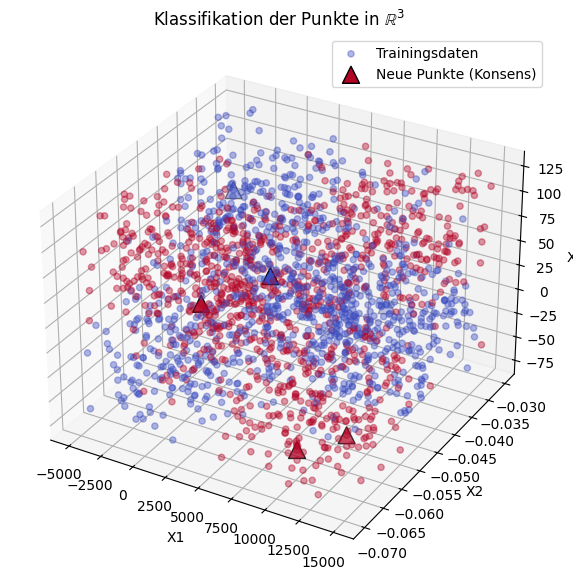

In [53]:
import matplotlib.pyplot as plt

# 3D-Scatterplot: Trainingsdaten (nach wahrer Klasse) und neue Punkte (nach Konsens-Vorhersage)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(train_data['X1'], train_data['X2'], train_data['X3'],
           c=train_data['Target'], cmap='coolwarm', alpha=0.4, label='Trainingsdaten')

consensus_new = [
    max(set(row), key=row.count)
    for row in zip(RFC_predictions, LR_predictions, SVM_predictions, GB_predictions, AB_predictions, ET_predictions)
]

ax.scatter(new_data['X1'], new_data['X2'], new_data['X3'],
           c=consensus_new, cmap='coolwarm', marker='^', s=150, edgecolor='black', label='Neue Punkte (Konsens)')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title(r'Klassifikation der Punkte in $\mathbb{R}^3$')
ax.legend()
plt.show()